# 04 — Alliance School Profile EDA

**Purpose:** define what an existing Alliance school looks like before evaluating future expansion candidates.

This notebook uses the SQLite database and the Program Power Index output to create league benchmarks across geography, resources, competitive strength, and institutional profile. The final benchmark table can become the foundation for a future expansion-evaluation app.

**Notebook sections**

1. Load schools table and Program Power Index  
2. Merge current league profile  
3. Explore geography and market distribution  
4. Explore resource distribution  
5. Explore competitive distribution  
6. Define Alliance benchmarks  
7. Export benchmark table for future expansion app  
8. Visualizations


## 0. Setup

Run this notebook from inside the project folder or from the `notebooks/` folder. The path logic below is designed to work in either case.

In [53]:
from pathlib import Path
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# Display settings
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

# --------------------------------------------------
# 0. Set project paths
# --------------------------------------------------
# Positron/Jupyter sometimes opens notebooks with a working directory that is
# not the project root. This block searches likely locations first, then falls
# back to Warren's known local project path.

known_project_root = Path(r"C:\Users\Warren Jones\OneDrive\Desktop\Alliance-SQL-DB")
candidates = [
    Path.cwd(),
    Path.cwd().parent,
    known_project_root,
]

PROJECT_ROOT = None
for candidate in candidates:
    if (candidate / "Database" / "alliance.db").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    checked = "\n".join(str(c / "Database" / "alliance.db") for c in candidates)
    raise FileNotFoundError(
        "Could not locate alliance.db. Checked:\n" + checked +
        "\n\nOpen this notebook from the Alliance-SQL-DB project folder or update known_project_root."
    )

DB_PATH = PROJECT_ROOT / "Database" / "alliance.db"
RAW_DIR = PROJECT_ROOT / "Data" / "Raw"
OUTPUT_DIR = PROJECT_ROOT / "Outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

POWER_INDEX_PATH = OUTPUT_DIR / "alliance_program_power_index.csv"
BENCHMARK_OUTPUT_PATH = OUTPUT_DIR / "alliance_school_profile_benchmarks.csv"
PROFILE_OUTPUT_PATH = OUTPUT_DIR / "alliance_current_school_profile.csv"

print("Project root:", PROJECT_ROOT)
print("Database path:", DB_PATH)
print("Raw data directory:", RAW_DIR)
print("Power Index path:", POWER_INDEX_PATH)
print("Output directory:", OUTPUT_DIR)

if not POWER_INDEX_PATH.exists():
    raise FileNotFoundError(
        f"Power Index not found at: {POWER_INDEX_PATH}\n"
        "Run scripts/03_program_power_index.py before running this notebook."
    )

print("Database and Program Power Index found.")


Project root: c:\Users\Warren Jones\OneDrive\Desktop\Alliance-SQL-DB
Database path: c:\Users\Warren Jones\OneDrive\Desktop\Alliance-SQL-DB\Database\alliance.db
Raw data directory: c:\Users\Warren Jones\OneDrive\Desktop\Alliance-SQL-DB\Data\Raw
Power Index path: c:\Users\Warren Jones\OneDrive\Desktop\Alliance-SQL-DB\Outputs\alliance_program_power_index.csv
Output directory: c:\Users\Warren Jones\OneDrive\Desktop\Alliance-SQL-DB\Outputs
Database and Program Power Index found.


## 1. Load schools table and Program Power Index

This section pulls the master `schools` table from SQLite and loads the Program Power Index CSV created by `03_program_power_index.py`.

In [54]:
# Connect to SQLite and load schools table
conn = sqlite3.connect(DB_PATH)

schools = pd.read_sql_query("SELECT * FROM schools ORDER BY school_id;", conn)

table_check = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
    ORDER BY name;
    """,
    conn
)

conn.close()

print("Tables available in alliance.db:")
display(table_check)

print("Schools shape:", schools.shape)
display(schools.head())
print("Schools columns:")
print(schools.columns.tolist())


Tables available in alliance.db:


,name
0,conference_championships
1,football_alltime_series_records
2,football_alltime_series_records_clean
3,football_coach_season_records
4,football_conference_championships
5,football_national_championships
6,football_playoff_results
7,football_program_data_raw
8,football_schedule_2026
9,football_schedule_2026_game_entries


Schools shape: (14, 21)


,school_id,school,fb_head_coach,first_season_as_head_coach,fb_head_coach_salary,asst_fb_coaches_salary_pool,state_championships_all_time,last_state_champ,alltime_wins,top25_ranked_weeks,last_year_ranked_t25_national_poll,2026_final_national_rank,ath__dept_budget,fb_expenses_non_salaries,total_fb_expenses,b_bb_budget,remaining_sports_budget_+_admin,total_sports,fb_season_tix_pct,media_total_minutes_watched,social_media_total_annual_impressions
0,1001,City College (MD),Messay Hailemariam,2014.0,NaN,"$380,000",32.0,2026.0,903.0,517.0,2026.0,2.0,"$5,455,152","$857,454","$2,390,106","$550,000","$2,515,046",27.0,0.35,"157,854,214","24,652,278"
1,1002,Central (PA),Tim Roken,2019.0,NaN,"$288,115",26.0,2024.0,753.0,368.0,2025.0,64.0,"$4,522,667","$507,585","$1,905,043","$407,541","$2,210,083",25.0,0.20,"101,747,858","15,025,244"
2,1003,PG Poly (MD),Bill McGregor,2017.0,NaN,"$250,036",12.0,2018.0,692.0,298.0,2023.0,82.0,"$4,211,593","$604,525","$1,840,420","$454,745","$1,916,428",23.0,0.27,"94,585,625","12,144,754"
3,1004,Brooklyn Tech (NY),Joe Spagnolo,2020.0,NaN,"$287,441",10.0,2025.0,481.0,21.0,2025.0,89.0,"$4,129,126","$358,758","$1,583,410","$587,602","$1,958,114",26.0,0.14,"98,545,858","13,447,485"
4,1005,Ramsey (NJ),Ryan Miller,2019.0,NaN,"$249,886",18.0,2023.0,562.0,19.0,2024.0,75.0,"$4,200,387","$317,852","$1,537,394","$407,508","$2,255,485",27.0,0.29,"56,654,748","6,855,787"


Schools columns:
['school_id', 'school', 'fb_head_coach', 'first_season_as_head_coach', 'fb_head_coach_salary', 'asst_fb_coaches_salary_pool', 'state_championships_all_time', 'last_state_champ', 'alltime_wins', 'top25_ranked_weeks', 'last_year_ranked_t25_national_poll', '2026_final_national_rank', 'ath__dept_budget', 'fb_expenses_non_salaries', 'total_fb_expenses', 'b_bb_budget', 'remaining_sports_budget_+_admin', 'total_sports', 'fb_season_tix_pct', 'media_total_minutes_watched', 'social_media_total_annual_impressions']


### 1A. Repair/augment school profile fields from raw program data

This notebook uses the database as the main source, but it also checks the raw `Football_Program_Data.csv` file for fields that may have been lost during earlier type conversion, especially currency fields like head coach salary. This keeps the EDA notebook stable while the build script is being refined.

In [55]:
# Repair/augment school profile fields from the raw Football_Program_Data.csv
# This is especially useful for currency fields that may have become NaN during an earlier build.

def clean_column_names_local(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = (
        df.columns
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
        .str.replace("/", "_", regex=False)
        .str.replace("%", "pct", regex=False)
        .str.replace(".", "", regex=False)
    )
    return df


def parse_currency(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.replace("(", "-", regex=False)
        .str.replace(")", "", regex=False)
        .str.strip()
        .replace({"": np.nan, "nan": np.nan, "None": np.nan}),
        errors="coerce"
    )


def normalize_school_name_local(value):
    if pd.isna(value):
        return value
    value = str(value).strip()
    value = value.replace("Steubenville (OH))", "Steubenville (OH)")
    value = value.replace("Mount Carmel (OH)", "Mount Carmel (IL)")
    return value

program_data_path = RAW_DIR / "Football_Program_Data.csv"

if program_data_path.exists():
    raw_programs = pd.read_csv(program_data_path)
    raw_programs = clean_column_names_local(raw_programs)

    raw_programs = raw_programs.dropna(how="all")
    raw_programs = raw_programs[
        raw_programs["school"].notna()
        & (raw_programs["school"].astype(str).str.strip() != "")
    ].copy()

    raw_programs["school"] = raw_programs["school"].apply(normalize_school_name_local)

    money_cols = [
        "fb_head_coach_salary",
        "asst_fb_coaches_salary_pool",
        "ath_dept_budget",
        "fb_expenses_non_salaries",
        "total_fb_expenses",
        "b_bb_budget",
        "remaining_sports_budget_+_admin",
    ]

    for col in money_cols:
        if col in raw_programs.columns:
            raw_programs[col] = parse_currency(raw_programs[col])

    # Apply known corrections inside the dataframe used by this notebook.
    salary_corrections = {
        "Jordan Lynch": 255000,
        "Chris Wolfe": 225000,
    }

    if {"fb_head_coach", "fb_head_coach_salary"}.issubset(raw_programs.columns):
        for coach, salary in salary_corrections.items():
            raw_programs.loc[
                raw_programs["fb_head_coach"] == coach,
                "fb_head_coach_salary"
            ] = salary

    # Fill missing values in schools from raw_programs without appending rows.
    schools = schools.copy()
    schools["school"] = schools["school"].apply(normalize_school_name_local)

    schools_indexed = schools.set_index("school", drop=False)
    raw_indexed = raw_programs.set_index("school", drop=False)

    for col in raw_indexed.columns:
        if col == "school":
            continue
        if col not in schools_indexed.columns:
            schools_indexed[col] = raw_indexed[col]
        else:
            schools_indexed[col] = schools_indexed[col].combine_first(raw_indexed[col])

    schools = schools_indexed.reset_index(drop=True)

    print("School profile fields augmented from raw Football_Program_Data.csv.")
    if {"school", "fb_head_coach", "fb_head_coach_salary"}.issubset(schools.columns):
        salary_check = schools[["school", "fb_head_coach", "fb_head_coach_salary"]].copy()
        salary_check["fb_head_coach_salary"] = pd.to_numeric(salary_check["fb_head_coach_salary"], errors="coerce")
        display(salary_check.sort_values("fb_head_coach_salary", ascending=False))
else:
    print(f"Raw program data file not found at: {program_data_path}")


School profile fields augmented from raw Football_Program_Data.csv.


,school,fb_head_coach,fb_head_coach_salary
0,City College (MD),Messay Hailemariam,350000.0
13,Massillon (OH),Nate Moore,300000.0
9,Steubenville (OH),Reno Saccoccia Jr.,263252.0
12,Moeller (OH),Bert Bathiany,257850.0
5,Phoebus (VA),Dan Sabella,257500.0
6,Oscar Smith (VA),Alonzo Cooley,257000.0
8,Mount Carmel (IL),Jordan Lynch,255000.0
1,Central (PA),Tim Roken,245000.0
2,PG Poly (MD),Bill McGregor,235750.0
3,Brooklyn Tech (NY),Joe Spagnolo,235000.0


In [56]:
# Load Program Power Index output
power_index = pd.read_csv(POWER_INDEX_PATH)

print("Power Index shape:", power_index.shape)
display(power_index.head())
print("Power Index columns:")
print(power_index.columns.tolist())


Power Index shape: (14, 22)


,power_rank,school_id,school,fb_head_coach,national_titles,conference_titles,alltime_wins,coach_wins,coach_losses,current_coach_win_pct,winning_series_count,avg_head_to_head_win_pct,fb_head_coach_salary,total_fb_expenses,ath_dept_budget,media_total_minutes_watched,social_media_total_annual_impressions,history_score,competitive_score,resource_score,program_power_index,program_archetype
0,1,1010,Steubenville (OH),Reno Saccoccia Jr.,11.0,10.0,1002.0,146,41,0.781,12,0.693,0.0,0.0,0,0.0,0.0,94.2,86.4,35.0,76.7,Culture Power
1,2,1001,City College (MD),Messay Hailemariam,7.0,12.0,903.0,147,17,0.896,12,0.748,0.0,0.0,0,0.0,0.0,79.8,100.0,35.0,75.7,Culture Power
2,3,1014,Massillon (OH),Nate Moore,11.0,2.0,987.0,109,34,0.762,8,0.527,0.0,0.0,0,0.0,0.0,70.3,65.8,35.0,59.9,Legacy Power
3,4,1002,Central (PA),Tim Roken,8.0,8.0,753.0,60,19,0.759,8,0.547,0.0,0.0,0,0.0,0.0,66.5,67.1,35.0,58.8,Volatile Talent Program
4,5,1009,Mount Carmel (IL),Jordan Lynch,0.0,9.0,702.0,63,32,0.663,6,0.508,255000.0,0.0,0,0.0,0.0,34.7,52.9,65.0,48.7,Resource-Backed Underachiever


Power Index columns:
['power_rank', 'school_id', 'school', 'fb_head_coach', 'national_titles', 'conference_titles', 'alltime_wins', 'coach_wins', 'coach_losses', 'current_coach_win_pct', 'winning_series_count', 'avg_head_to_head_win_pct', 'fb_head_coach_salary', 'total_fb_expenses', 'ath_dept_budget', 'media_total_minutes_watched', 'social_media_total_annual_impressions', 'history_score', 'competitive_score', 'resource_score', 'program_power_index', 'program_archetype']


## 2. Merge current league profile

This creates one current-league profile table by joining the core school profile with the Program Power Index.

In [57]:
# --------------------------------------------------
# Build current league profile
# --------------------------------------------------
# The database's schools table is the authoritative source for program-level
# fields. The Program Power Index contributes derived competitive/history/resource
# scores. We also derive state/division fields if they are not present.

league_base = schools.copy()

# Derive state abbreviation from school name if no state column exists.
if "state" not in league_base.columns:
    league_base["state"] = league_base["school"].str.extract(r"\(([^)]+)\)$")

# Derive a simple East/West division from the official school_id map if no division column exists.
if "division" not in league_base.columns:
    east_ids = {1001, 1002, 1003, 1004, 1005, 1006, 1007}
    league_base["division"] = np.where(league_base["school_id"].isin(east_ids), "East", "West")

# Add city if the database does not currently carry one. This keeps EDA cells stable.
if "city" not in league_base.columns:
    city_map = {
        "City College (MD)": "Baltimore",
        "Central (PA)": "Philadelphia",
        "PG Poly (MD)": "Hyattsville",
        "Brooklyn Tech (NY)": "Brooklyn",
        "Ramsey (NJ)": "Ramsey",
        "Phoebus (VA)": "Norfolk / Hampton Roads",
        "Oscar Smith (VA)": "Chesapeake",
        "Canton McKinley (OH)": "Canton",
        "Mount Carmel (IL)": "Chicago",
        "Steubenville (OH)": "Steubenville",
        "Male (KY)": "Louisville",
        "East St. Louis (IL)": "East St. Louis",
        "Moeller (OH)": "Cincinnati",
        "Massillon (OH)": "Massillon",
    }
    league_base["city"] = league_base["school"].map(city_map)

# Avoid duplicate columns from the Power Index if they already exist in schools.
power_cols_to_merge = [
    "school_id",
    "power_rank",
    "history_score",
    "competitive_score",
    "resource_score",
    "program_power_index",
    "program_archetype",
    "national_titles",
    "conference_titles",
    "coach_wins",
    "coach_losses",
    "current_coach_win_pct",
    "winning_series_count",
    "avg_head_to_head_win_pct",
]

power_cols_to_merge = [col for col in power_cols_to_merge if col in power_index.columns]

# Drop any fields from the base that will be replaced by Power Index derived metrics.
cols_to_replace = [col for col in power_cols_to_merge if col != "school_id" and col in league_base.columns]
league_base = league_base.drop(columns=cols_to_replace)

league_profile = league_base.merge(
    power_index[power_cols_to_merge],
    on="school_id",
    how="left",
    suffixes=("", "_ppi")
)

print("Merged league profile shape:", league_profile.shape)
display(league_profile.head())
print("Merged league profile columns:")
print(league_profile.columns.tolist())


Merged league profile shape: (14, 37)


,school_id,school,fb_head_coach,first_season_as_head_coach,fb_head_coach_salary,asst_fb_coaches_salary_pool,state_championships_all_time,last_state_champ,alltime_wins,top25_ranked_weeks,last_year_ranked_t25_national_poll,2026_final_national_rank,ath__dept_budget,fb_expenses_non_salaries,total_fb_expenses,b_bb_budget,remaining_sports_budget_+_admin,total_sports,fb_season_tix_pct,media_total_minutes_watched,social_media_total_annual_impressions,state,division,city,power_rank,history_score,competitive_score,resource_score,program_power_index,program_archetype,national_titles,conference_titles,coach_wins,coach_losses,current_coach_win_pct,winning_series_count,avg_head_to_head_win_pct
0,1001,City College (MD),Messay Hailemariam,2014.0,350000.0,"$380,000",32.0,2026.0,903.0,517.0,2026.0,2.0,"$5,455,152","$857,454","$2,390,106","$550,000","$2,515,046",27.0,0.35,"157,854,214","24,652,278",MD,East,Baltimore,2,79.8,100.0,35.0,75.7,Culture Power,7.0,12.0,147,17,0.896,12,0.748
1,1002,Central (PA),Tim Roken,2019.0,245000.0,"$288,115",26.0,2024.0,753.0,368.0,2025.0,64.0,"$4,522,667","$507,585","$1,905,043","$407,541","$2,210,083",25.0,0.20,"101,747,858","15,025,244",PA,East,Philadelphia,4,66.5,67.1,35.0,58.8,Volatile Talent Program,8.0,8.0,60,19,0.759,8,0.547
2,1003,PG Poly (MD),Bill McGregor,2017.0,235750.0,"$250,036",12.0,2018.0,692.0,298.0,2023.0,82.0,"$4,211,593","$604,525","$1,840,420","$454,745","$1,916,428",23.0,0.27,"94,585,625","12,144,754",MD,East,Hyattsville,13,11.0,29.6,35.0,23.5,Development / Rebuild Program,0.0,1.0,45,38,0.542,2,0.418
3,1004,Brooklyn Tech (NY),Joe Spagnolo,2020.0,235000.0,"$287,441",10.0,2025.0,481.0,21.0,2025.0,89.0,"$4,129,126","$358,758","$1,583,410","$587,602","$1,958,114",26.0,0.14,"98,545,858","13,447,485",NY,East,Brooklyn,14,0.0,26.1,35.0,17.9,Development / Rebuild Program,0.0,0.0,44,22,0.667,0,0.278
4,1005,Ramsey (NJ),Ryan Miller,2019.0,235000.0,"$249,886",18.0,2023.0,562.0,19.0,2024.0,75.0,"$4,200,387","$317,852","$1,537,394","$407,508","$2,255,485",27.0,0.29,"56,654,748","6,855,787",NJ,East,Ramsey,10,32.9,45.4,35.0,37.8,Development / Rebuild Program,3.0,6.0,52,24,0.684,3,0.451


Merged league profile columns:
['school_id', 'school', 'fb_head_coach', 'first_season_as_head_coach', 'fb_head_coach_salary', 'asst_fb_coaches_salary_pool', 'state_championships_all_time', 'last_state_champ', 'alltime_wins', 'top25_ranked_weeks', 'last_year_ranked_t25_national_poll', '2026_final_national_rank', 'ath__dept_budget', 'fb_expenses_non_salaries', 'total_fb_expenses', 'b_bb_budget', 'remaining_sports_budget_+_admin', 'total_sports', 'fb_season_tix_pct', 'media_total_minutes_watched', 'social_media_total_annual_impressions', 'state', 'division', 'city', 'power_rank', 'history_score', 'competitive_score', 'resource_score', 'program_power_index', 'program_archetype', 'national_titles', 'conference_titles', 'coach_wins', 'coach_losses', 'current_coach_win_pct', 'winning_series_count', 'avg_head_to_head_win_pct']


In [58]:
# Standardize likely numeric columns for EDA.
# Currency-like columns are cleaned before numeric conversion so values such as "$255,000" do not become NaN.
potential_numeric_cols = [
    "enrollment",
    "msa_size_millions_2035",
    "football_capacity",
    "3yr_avg_fb_attendance",
    "fb_head_coach_salary",
    "asst_fb_coaches_salary_pool",
    "ath_dept_budget",
    "fb_expenses_non_salaries",
    "total_fb_expenses",
    "b_bb_budget",
    "remaining_sports_budget_+_admin",
    "total_sports",
    "fb_season_tix_pct",
    "media_total_minutes_watched",
    "social_media_total_annual_impressions",
    "state_championships_all_time",
    "last_state_champ",
    "alltime_wins",
    "top25_ranked_weeks",
    "last_year_ranked_t25_national_poll",
    "2026_final_national_rank",
    "national_titles",
    "conference_titles",
    "coach_wins",
    "coach_losses",
    "current_coach_win_pct",
    "winning_series_count",
    "avg_head_to_head_win_pct",
    "history_score",
    "competitive_score",
    "resource_score",
    "program_power_index",
]

currency_like_cols = {
    "fb_head_coach_salary",
    "asst_fb_coaches_salary_pool",
    "ath_dept_budget",
    "fb_expenses_non_salaries",
    "total_fb_expenses",
    "b_bb_budget",
    "remaining_sports_budget_+_admin",
}

for col in potential_numeric_cols:
    if col in league_profile.columns:
        if col in currency_like_cols:
            league_profile[col] = parse_currency(league_profile[col])
        else:
            league_profile[col] = pd.to_numeric(league_profile[col], errors="coerce")

# Salary sanity check after augmentation/correction.
salary_cols = [col for col in ["school", "fb_head_coach", "fb_head_coach_salary"] if col in league_profile.columns]
if salary_cols:
    print("Salary sanity check:")
    salary_view = league_profile[salary_cols].copy()
    salary_view["fb_head_coach_salary"] = pd.to_numeric(salary_view["fb_head_coach_salary"], errors="coerce")
    display(salary_view.sort_values("fb_head_coach_salary", ascending=False))

# Save merged profile for reuse.
league_profile.to_csv(PROFILE_OUTPUT_PATH, index=False)
print("Current league profile exported to:", PROFILE_OUTPUT_PATH)


Salary sanity check:


,school,fb_head_coach,fb_head_coach_salary
0,City College (MD),Messay Hailemariam,350000.0
13,Massillon (OH),Nate Moore,300000.0
9,Steubenville (OH),Reno Saccoccia Jr.,263252.0
12,Moeller (OH),Bert Bathiany,257850.0
5,Phoebus (VA),Dan Sabella,257500.0
6,Oscar Smith (VA),Alonzo Cooley,257000.0
8,Mount Carmel (IL),Jordan Lynch,255000.0
1,Central (PA),Tim Roken,245000.0
2,PG Poly (MD),Bill McGregor,235750.0
3,Brooklyn Tech (NY),Joe Spagnolo,235000.0


Current league profile exported to: c:\Users\Warren Jones\OneDrive\Desktop\Alliance-SQL-DB\Outputs\alliance_current_school_profile.csv


## 3. Explore geography and market distribution

This section looks at geography, division balance, state footprint, and market profile. The notebook will use whichever geography fields are available in the `schools` table.

In [59]:

geo_cols = [
    col for col in [
        "school_id", "school", "division", "city", "state", "enrollment", "msa_size_millions_2035"
    ] if col in league_profile.columns
]

geo_profile = league_profile[geo_cols].copy()
print("Available geography columns:", geo_cols)
display(geo_profile)


Available geography columns: ['school_id', 'school', 'division', 'city', 'state']


,school_id,school,division,city,state
0,1001,City College (MD),East,Baltimore,MD
1,1002,Central (PA),East,Philadelphia,PA
2,1003,PG Poly (MD),East,Hyattsville,MD
3,1004,Brooklyn Tech (NY),East,Brooklyn,NY
4,1005,Ramsey (NJ),East,Ramsey,NJ
5,1006,Phoebus (VA),East,Norfolk / Hampton Roads,VA
6,1007,Oscar Smith (VA),East,Chesapeake,VA
7,1008,Canton McKinley (OH),West,Canton,OH
8,1009,Mount Carmel (IL),West,Chicago,IL
9,1010,Steubenville (OH),West,Steubenville,OH


In [60]:

# State footprint
if "state" in league_profile.columns:
    state_counts = (
        league_profile
        .groupby("state", dropna=False)
        .agg(schools=("school_id", "count"),
             avg_power_index=("program_power_index", "mean"),
             avg_competitive_score=("competitive_score", "mean"))
        .reset_index()
        .sort_values(["schools", "avg_power_index"], ascending=[False, False])
    )
    display(state_counts)
else:
    print("No state column available in schools table.")


,state,schools,avg_power_index,avg_competitive_score
5,OH,4,51.70,50.225
2,MD,2,49.60,64.800
0,IL,2,44.70,53.500
7,VA,2,35.95,49.050
6,PA,1,58.80,67.100
1,KY,1,40.80,38.200
3,NJ,1,37.80,45.400
4,NY,1,17.90,26.100


In [61]:

# Division balance
if "division" in league_profile.columns:
    division_summary = (
        league_profile
        .groupby("division", dropna=False)
        .agg(
            schools=("school_id", "count"),
            avg_enrollment=("enrollment", "mean") if "enrollment" in league_profile.columns else ("school_id", "count"),
            avg_power_index=("program_power_index", "mean"),
            avg_competitive_score=("competitive_score", "mean"),
            avg_resource_score=("resource_score", "mean")
        )
        .reset_index()
    )
    display(division_summary)
else:
    print("No division column available in schools table.")


,division,schools,avg_enrollment,avg_power_index,avg_competitive_score,avg_resource_score
0,East,7,7,40.800000,52.328571,35.000000
1,West,7,7,48.142857,49.442857,43.071429


In [62]:

# Market size summary, if available
if "msa_size_millions_2035" in league_profile.columns:
    market_summary = league_profile[["school", "msa_size_millions_2035", "program_power_index"]].sort_values(
        "msa_size_millions_2035", ascending=False
    )
    display(market_summary)
else:
    print("No MSA size column available. Consider adding geography/stadium profile data to the schools table later.")


No MSA size column available. Consider adding geography/stadium profile data to the schools table later.


## 4. Explore resource distribution

This section profiles the league’s resource base. For expansion evaluation, these fields help identify whether a candidate school invests like an Alliance member.

In [63]:

resource_cols = [
    col for col in [
        "school", "fb_head_coach", "fb_head_coach_salary", "asst_fb_coaches_salary_pool",
        "ath_dept_budget", "fb_expenses_non_salaries", "total_fb_expenses",
        "football_capacity", "3yr_avg_fb_attendance", "media_total_minutes_watched",
        "social_media_total_annual_impressions", "resource_score", "program_power_index"
    ] if col in league_profile.columns
]

resource_profile = league_profile[resource_cols].copy()
print("Available resource columns:", resource_cols)
display(resource_profile.sort_values("resource_score", ascending=False) if "resource_score" in resource_profile.columns else resource_profile)


Available resource columns: ['school', 'fb_head_coach', 'fb_head_coach_salary', 'asst_fb_coaches_salary_pool', 'fb_expenses_non_salaries', 'total_fb_expenses', 'media_total_minutes_watched', 'social_media_total_annual_impressions', 'resource_score', 'program_power_index']


,school,fb_head_coach,fb_head_coach_salary,asst_fb_coaches_salary_pool,fb_expenses_non_salaries,total_fb_expenses,media_total_minutes_watched,social_media_total_annual_impressions,resource_score,program_power_index
8,Mount Carmel (IL),Jordan Lynch,255000.0,242464,358411,1450266,NaN,NaN,65.0,48.7
10,Male (KY),Chris Wolfe,225000.0,275313,425141,1742343,NaN,NaN,61.5,40.8
2,PG Poly (MD),Bill McGregor,235750.0,250036,604525,1840420,NaN,NaN,35.0,23.5
3,Brooklyn Tech (NY),Joe Spagnolo,235000.0,287441,358758,1583410,NaN,NaN,35.0,17.9
0,City College (MD),Messay Hailemariam,350000.0,380000,857454,2390106,NaN,NaN,35.0,75.7
1,Central (PA),Tim Roken,245000.0,288115,507585,1905043,NaN,NaN,35.0,58.8
5,Phoebus (VA),Dan Sabella,257500.0,296369,808542,2219017,NaN,NaN,35.0,32.8
4,Ramsey (NJ),Ryan Miller,235000.0,249886,317852,1537394,NaN,NaN,35.0,37.8
7,Canton McKinley (OH),Chris Scott,225500.0,275604,903225,2262640,NaN,NaN,35.0,29.8
6,Oscar Smith (VA),Alonzo Cooley,257000.0,312500,936000,2443500,NaN,NaN,35.0,39.1


In [64]:

# Resource descriptive statistics
resource_metric_cols = [
    col for col in [
        "fb_head_coach_salary", "asst_fb_coaches_salary_pool", "ath_dept_budget",
        "fb_expenses_non_salaries", "total_fb_expenses", "football_capacity",
        "3yr_avg_fb_attendance", "media_total_minutes_watched",
        "social_media_total_annual_impressions", "resource_score"
    ] if col in league_profile.columns
]

resource_summary = league_profile[resource_metric_cols].describe().T if resource_metric_cols else pd.DataFrame()
display(resource_summary)


,count,mean,std,min,25%,50%,75%,max
fb_head_coach_salary,14.0,2.545187e+05,34308.919788,221410.0,235000.00,250000.0,257762.50,350000.0
asst_fb_coaches_salary_pool,14.0,2.904170e+05,40262.303018,242464.0,256782.75,284415.0,308467.25,380000.0
fb_expenses_non_salaries,14.0,6.094541e+05,225295.207727,317852.0,406178.00,556055.0,805369.50,936000.0
total_fb_expenses,14.0,1.968228e+06,351237.077691,1450266.0,1680684.75,1878524.0,2307028.00,2443500.0
media_total_minutes_watched,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
social_media_total_annual_impressions,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
resource_score,14.0,3.903571e+01,10.281545,35.0,35.00,35.0,35.00,65.0


In [65]:

# Programs that appear to over/underperform relative to resources
if {"competitive_score", "resource_score"}.issubset(league_profile.columns):
    resource_gap = league_profile[["school", "competitive_score", "resource_score", "program_power_index", "program_archetype"]].copy()
    resource_gap["competitive_minus_resource"] = resource_gap["competitive_score"] - resource_gap["resource_score"]
    resource_gap = resource_gap.sort_values("competitive_minus_resource", ascending=False)
    display(resource_gap)
else:
    print("competitive_score/resource_score not available.")


,school,competitive_score,resource_score,program_power_index,program_archetype,competitive_minus_resource
0,City College (MD),100.0,35.0,75.7,Culture Power,65.0
9,Steubenville (OH),86.4,35.0,76.7,Culture Power,51.4
1,Central (PA),67.1,35.0,58.8,Volatile Talent Program,32.1
13,Massillon (OH),65.8,35.0,59.9,Legacy Power,30.8
6,Oscar Smith (VA),54.3,35.0,39.1,Development / Rebuild Program,19.3
11,East St. Louis (IL),54.1,35.0,40.7,Volatile Talent Program,19.1
4,Ramsey (NJ),45.4,35.0,37.8,Development / Rebuild Program,10.4
5,Phoebus (VA),43.8,35.0,32.8,Development / Rebuild Program,8.8
2,PG Poly (MD),29.6,35.0,23.5,Development / Rebuild Program,-5.4
3,Brooklyn Tech (NY),26.1,35.0,17.9,Development / Rebuild Program,-8.9


## 5. Explore competitive distribution

This section looks at competitive strength using titles, coaching record, head-to-head dominance, and the Program Power Index.

In [66]:

competitive_cols = [
    col for col in [
        "school", "fb_head_coach", "national_titles", "conference_titles",
        "coach_wins", "coach_losses", "current_coach_win_pct",
        "winning_series_count", "avg_head_to_head_win_pct",
        "history_score", "competitive_score", "program_power_index", "program_archetype"
    ] if col in league_profile.columns
]

competitive_profile = league_profile[competitive_cols].copy()
display(competitive_profile.sort_values("program_power_index", ascending=False))


,school,fb_head_coach,national_titles,conference_titles,coach_wins,coach_losses,current_coach_win_pct,winning_series_count,avg_head_to_head_win_pct,history_score,competitive_score,program_power_index,program_archetype
9,Steubenville (OH),Reno Saccoccia Jr.,11.0,10.0,146,41,0.781,12,0.693,94.2,86.4,76.7,Culture Power
0,City College (MD),Messay Hailemariam,7.0,12.0,147,17,0.896,12,0.748,79.8,100.0,75.7,Culture Power
13,Massillon (OH),Nate Moore,11.0,2.0,109,34,0.762,8,0.527,70.3,65.8,59.9,Legacy Power
1,Central (PA),Tim Roken,8.0,8.0,60,19,0.759,8,0.547,66.5,67.1,58.8,Volatile Talent Program
8,Mount Carmel (IL),Jordan Lynch,0.0,9.0,63,32,0.663,6,0.508,34.7,52.9,48.7,Resource-Backed Underachiever
10,Male (KY),Chris Wolfe,1.0,3.0,117,66,0.639,2,0.427,30.2,38.2,40.8,Resource-Backed Underachiever
11,East St. Louis (IL),Darren Sunkett,1.0,5.0,33,28,0.541,9,0.592,32.5,54.1,40.7,Volatile Talent Program
12,Moeller (OH),Bert Bathiany,5.0,9.0,29,23,0.558,1,0.370,56.6,25.7,40.4,Volatile Talent Program
6,Oscar Smith (VA),Alonzo Cooley,1.0,4.0,228,87,0.724,5,0.482,28.3,54.3,39.1,Development / Rebuild Program
4,Ramsey (NJ),Ryan Miller,3.0,6.0,52,24,0.684,3,0.451,32.9,45.4,37.8,Development / Rebuild Program


In [67]:

# Archetype summary
if "program_archetype" in league_profile.columns:
    archetype_summary = (
        league_profile
        .groupby("program_archetype", dropna=False)
        .agg(
            programs=("school_id", "count"),
            avg_power_index=("program_power_index", "mean"),
            avg_history_score=("history_score", "mean"),
            avg_competitive_score=("competitive_score", "mean"),
            avg_resource_score=("resource_score", "mean"),
        )
        .reset_index()
        .sort_values("avg_power_index", ascending=False)
    )
    display(archetype_summary)
else:
    print("No program_archetype column available.")


,program_archetype,programs,avg_power_index,avg_history_score,avg_competitive_score,avg_resource_score
0,Culture Power,2,76.200000,87.000000,93.200000,35.00
2,Legacy Power,1,59.900000,70.300000,65.800000,35.00
4,Volatile Talent Program,3,46.633333,51.866667,48.966667,35.00
3,Resource-Backed Underachiever,2,44.750000,32.450000,45.550000,63.25
1,Development / Rebuild Program,6,30.150000,21.100000,37.033333,35.00


In [68]:

# Legacy gap: history relative to current competitiveness
if {"history_score", "competitive_score"}.issubset(league_profile.columns):
    legacy_gap = league_profile[["school", "history_score", "competitive_score", "program_power_index", "program_archetype"]].copy()
    legacy_gap["legacy_gap"] = legacy_gap["history_score"] - legacy_gap["competitive_score"]
    display(legacy_gap.sort_values("legacy_gap", ascending=False))
else:
    print("history_score/competitive_score not available.")


,school,history_score,competitive_score,program_power_index,program_archetype,legacy_gap
12,Moeller (OH),56.6,25.7,40.4,Volatile Talent Program,30.9
7,Canton McKinley (OH),32.6,23.0,29.8,Development / Rebuild Program,9.6
9,Steubenville (OH),94.2,86.4,76.7,Culture Power,7.8
13,Massillon (OH),70.3,65.8,59.9,Legacy Power,4.5
1,Central (PA),66.5,67.1,58.8,Volatile Talent Program,-0.6
10,Male (KY),30.2,38.2,40.8,Resource-Backed Underachiever,-8.0
4,Ramsey (NJ),32.9,45.4,37.8,Development / Rebuild Program,-12.5
8,Mount Carmel (IL),34.7,52.9,48.7,Resource-Backed Underachiever,-18.2
2,PG Poly (MD),11.0,29.6,23.5,Development / Rebuild Program,-18.6
0,City College (MD),79.8,100.0,75.7,Culture Power,-20.2


## 6. Define Alliance benchmarks

This section builds the benchmark table that a future expansion app can use. The benchmark table summarizes the current Alliance distribution for key variables.

Interpretation idea:

- **Minimum viable threshold:** 25th percentile  
- **Typical Alliance profile:** median  
- **Strong Alliance profile:** 75th percentile  
- **Elite benchmark:** max or 90th percentile depending the metric  


In [69]:

benchmark_candidate_cols = [
    "enrollment",
    "msa_size_millions_2035",
    "fb_head_coach_salary",
    "asst_fb_coaches_salary_pool",
    "ath_dept_budget",
    "fb_expenses_non_salaries",
    "total_fb_expenses",
    "football_capacity",
    "3yr_avg_fb_attendance",
    "media_total_minutes_watched",
    "social_media_total_annual_impressions",
    "national_titles",
    "conference_titles",
    "coach_wins",
    "current_coach_win_pct",
    "winning_series_count",
    "avg_head_to_head_win_pct",
    "history_score",
    "competitive_score",
    "resource_score",
    "program_power_index",
]

benchmark_cols = [col for col in benchmark_candidate_cols if col in league_profile.columns]
print("Benchmark columns used:")
print(benchmark_cols)


Benchmark columns used:
['fb_head_coach_salary', 'asst_fb_coaches_salary_pool', 'fb_expenses_non_salaries', 'total_fb_expenses', 'media_total_minutes_watched', 'social_media_total_annual_impressions', 'national_titles', 'conference_titles', 'coach_wins', 'current_coach_win_pct', 'winning_series_count', 'avg_head_to_head_win_pct', 'history_score', 'competitive_score', 'resource_score', 'program_power_index']


In [71]:

benchmark_rows = []

for col in benchmark_cols:
    series = pd.to_numeric(league_profile[col], errors="coerce").dropna()
    if series.empty:
        continue

    benchmark_rows.append({
        "metric": col,
        "count": int(series.count()),
        "min": series.min(),
        "p25_minimum_viable": series.quantile(0.25),
        "median_typical_alliance": series.median(),
        "mean": series.mean(),
        "p75_strong_alliance": series.quantile(0.75),
        "p90_elite_benchmark": series.quantile(0.90),
        "max": series.max(),
    })

benchmarks = pd.DataFrame(benchmark_rows)

# Round numeric values for readability
for col in benchmarks.columns:
    if col != "metric":
        benchmarks[col] = pd.to_numeric(benchmarks[col], errors="coerce")

        if pd.api.types.is_numeric_dtype(benchmarks[col]):
            benchmarks[col] = benchmarks[col].round(2)

display(benchmarks)


,metric,count,min,p25_minimum_viable,median_typical_alliance,mean,p75_strong_alliance,p90_elite_benchmark,max
0,fb_head_coach_salary,14,221410.00,235000.00,250000.00,254518.71,257762.50,288975.60,350000.00
1,asst_fb_coaches_salary_pool,14,242464.00,256782.75,284415.00,290417.00,308467.25,342834.50,380000.00
2,fb_expenses_non_salaries,14,317852.00,406178.00,556055.00,609454.07,805369.50,889493.70,936000.00
3,total_fb_expenses,14,1450266.00,1680684.75,1878524.00,1968228.14,2307028.00,2377202.40,2443500.00
4,national_titles,14,0.00,0.25,1.50,3.57,6.50,10.10,11.00
5,conference_titles,14,0.00,3.00,4.50,5.36,8.75,9.70,12.00
6,coach_wins,14,7.00,36.50,56.00,79.57,115.00,146.70,228.00
7,current_coach_win_pct,14,0.35,0.55,0.66,0.65,0.75,0.78,0.90
8,winning_series_count,14,0.00,2.25,6.00,5.79,8.00,11.10,12.00
9,avg_head_to_head_win_pct,14,0.28,0.43,0.49,0.50,0.54,0.66,0.75


In [72]:

# Add a simple expansion relevance category to each benchmark metric
competitive_metrics = {
    "national_titles", "conference_titles", "coach_wins", "current_coach_win_pct",
    "winning_series_count", "avg_head_to_head_win_pct", "history_score",
    "competitive_score", "program_power_index"
}
resource_metrics = {
    "fb_head_coach_salary", "asst_fb_coaches_salary_pool", "ath_dept_budget",
    "fb_expenses_non_salaries", "total_fb_expenses", "football_capacity",
    "3yr_avg_fb_attendance", "resource_score"
}
market_metrics = {
    "enrollment", "msa_size_millions_2035", "media_total_minutes_watched",
    "social_media_total_annual_impressions"
}


def metric_category(metric):
    if metric in competitive_metrics:
        return "Competitive Fit"
    if metric in resource_metrics:
        return "Resource Fit"
    if metric in market_metrics:
        return "Market / Institutional Fit"
    return "Other"

benchmarks["expansion_category"] = benchmarks["metric"].apply(metric_category)
benchmarks = benchmarks[["expansion_category"] + [col for col in benchmarks.columns if col != "expansion_category"]]

display(benchmarks.sort_values(["expansion_category", "metric"]))


,expansion_category,metric,count,min,p25_minimum_viable,median_typical_alliance,mean,p75_strong_alliance,p90_elite_benchmark,max
9,Competitive Fit,avg_head_to_head_win_pct,14,0.28,0.43,0.49,0.50,0.54,0.66,0.75
6,Competitive Fit,coach_wins,14,7.00,36.50,56.00,79.57,115.00,146.70,228.00
11,Competitive Fit,competitive_score,14,23.00,31.75,49.15,50.89,62.92,80.61,100.00
5,Competitive Fit,conference_titles,14,0.00,3.00,4.50,5.36,8.75,9.70,12.00
7,Competitive Fit,current_coach_win_pct,14,0.35,0.55,0.66,0.65,0.75,0.78,0.90
10,Competitive Fit,history_score,14,0.00,28.78,32.75,42.24,64.03,76.95,94.20
4,Competitive Fit,national_titles,14,0.00,0.25,1.50,3.57,6.50,10.10,11.00
13,Competitive Fit,program_power_index,14,17.90,34.05,40.55,44.47,56.28,70.96,76.70
8,Competitive Fit,winning_series_count,14,0.00,2.25,6.00,5.79,8.00,11.10,12.00
1,Resource Fit,asst_fb_coaches_salary_pool,14,242464.00,256782.75,284415.00,290417.00,308467.25,342834.50,380000.00


## 7. Export benchmark table for future expansion app

This table can become the basis for a future app where candidate schools are scored against Alliance norms.

In [73]:
benchmarks.to_csv(BENCHMARK_OUTPUT_PATH, index=False)
print("Benchmark table exported to:", BENCHMARK_OUTPUT_PATH)

# Optional: create a compact candidate-scoring template for the future expansion app.
candidate_template_cols = [
    "candidate_school",
    "city",
    "state",
    "division_fit",
    "public_school_confirmed",
    "enrollment",
    "msa_size_millions_2035",
    "fb_head_coach_salary",
    "asst_fb_coaches_salary_pool",
    "ath_dept_budget",
    "total_fb_expenses",
    "football_capacity",
    "3yr_avg_fb_attendance",
    "media_total_minutes_watched",
    "social_media_total_annual_impressions",
    "national_titles",
    "conference_titles",
    "state_titles",
    "recent_win_pct",
    "recent_national_rankings",
    "distance_to_nearest_alliance_school",
    "notes",
]

candidate_template = pd.DataFrame(columns=candidate_template_cols)
candidate_template_path = OUTPUT_DIR / "expansion_candidate_template.csv"
candidate_template.to_csv(candidate_template_path, index=False)
print("Expansion candidate template exported to:", candidate_template_path)


Benchmark table exported to: c:\Users\Warren Jones\OneDrive\Desktop\Alliance-SQL-DB\Outputs\alliance_school_profile_benchmarks.csv
Expansion candidate template exported to: c:\Users\Warren Jones\OneDrive\Desktop\Alliance-SQL-DB\Outputs\expansion_candidate_template.csv


## 8. Visualizations

These charts are meant to make the league profile easier to interpret visually. They use the current member schools only; future versions can overlay expansion candidates against these distributions.

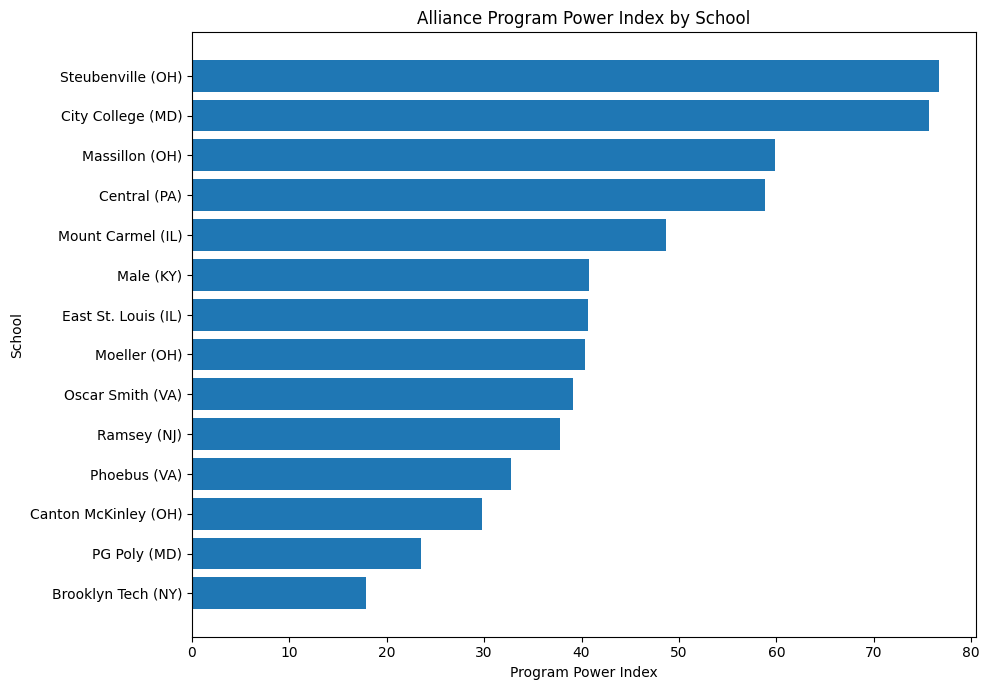

In [74]:

# Visualization 1: Program Power Index ranking
if "program_power_index" in league_profile.columns:
    plot_df = league_profile.sort_values("program_power_index", ascending=True)

    plt.figure(figsize=(10, 7))
    plt.barh(plot_df["school"], plot_df["program_power_index"])
    plt.xlabel("Program Power Index")
    plt.ylabel("School")
    plt.title("Alliance Program Power Index by School")
    plt.tight_layout()
    plt.show()
else:
    print("program_power_index not available.")


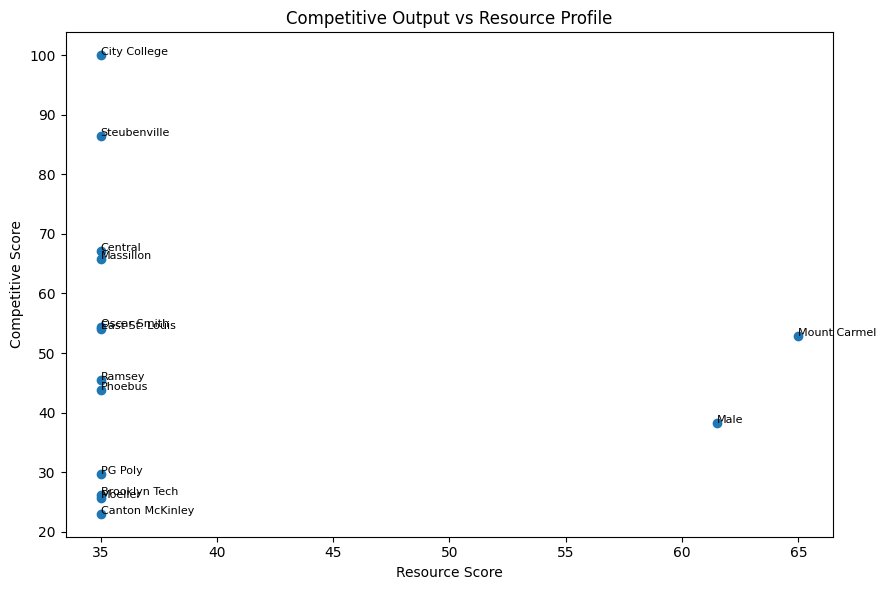

In [75]:

# Visualization 2: Competitive score vs resource score
if {"competitive_score", "resource_score"}.issubset(league_profile.columns):
    plt.figure(figsize=(9, 6))
    plt.scatter(league_profile["resource_score"], league_profile["competitive_score"])

    for _, row in league_profile.iterrows():
        plt.annotate(row["school"].split(" (")[0], (row["resource_score"], row["competitive_score"]), fontsize=8)

    plt.xlabel("Resource Score")
    plt.ylabel("Competitive Score")
    plt.title("Competitive Output vs Resource Profile")
    plt.tight_layout()
    plt.show()
else:
    print("competitive_score/resource_score not available.")


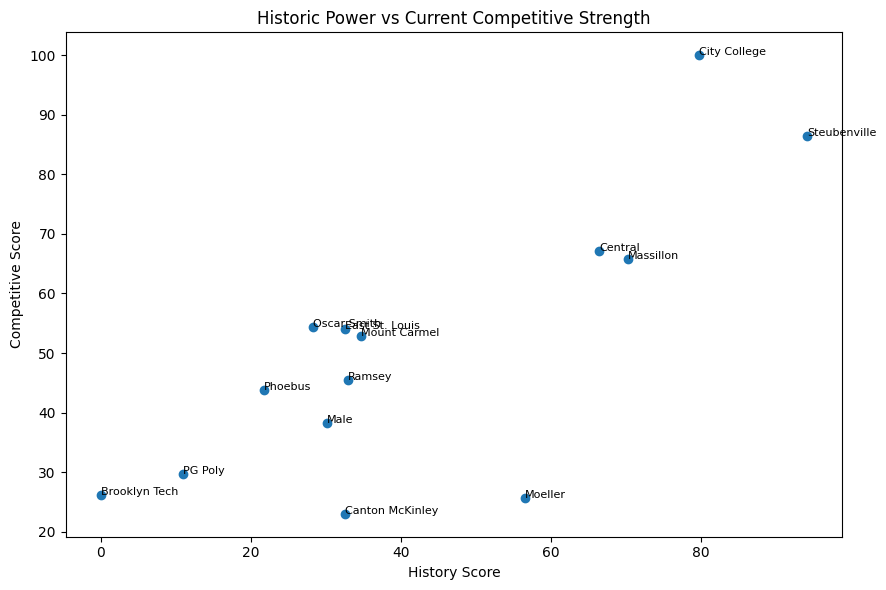

In [76]:

# Visualization 3: History score vs competitive score
if {"history_score", "competitive_score"}.issubset(league_profile.columns):
    plt.figure(figsize=(9, 6))
    plt.scatter(league_profile["history_score"], league_profile["competitive_score"])

    for _, row in league_profile.iterrows():
        plt.annotate(row["school"].split(" (")[0], (row["history_score"], row["competitive_score"]), fontsize=8)

    plt.xlabel("History Score")
    plt.ylabel("Competitive Score")
    plt.title("Historic Power vs Current Competitive Strength")
    plt.tight_layout()
    plt.show()
else:
    print("history_score/competitive_score not available.")


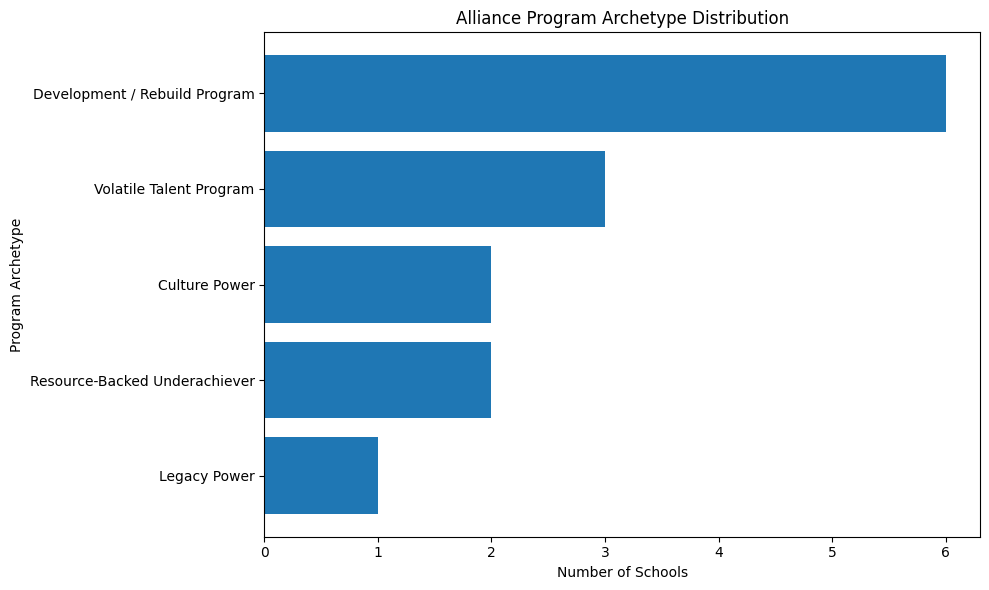

In [77]:

# Visualization 4: Archetype counts
if "program_archetype" in league_profile.columns:
    archetype_counts = league_profile["program_archetype"].value_counts().sort_values()

    plt.figure(figsize=(10, 6))
    plt.barh(archetype_counts.index, archetype_counts.values)
    plt.xlabel("Number of Schools")
    plt.ylabel("Program Archetype")
    plt.title("Alliance Program Archetype Distribution")
    plt.tight_layout()
    plt.show()
else:
    print("program_archetype not available.")


In [ ]:

# Visualization 5: Distribution of key benchmark scores
score_cols = [col for col in ["history_score", "competitive_score", "resource_score", "program_power_index"] if col in league_profile.columns]

for col in score_cols:
    plt.figure(figsize=(8, 5))
    plt.hist(league_profile[col].dropna(), bins=6)
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel("Number of Schools")
    plt.title(f"Distribution of {col.replace('_', ' ').title()}")
    plt.tight_layout()
    plt.show()


## EDA Takeaways Draft

Use this section after running the notebook to write your interpretation.

Questions to answer:

1. What is the typical Alliance school profile?
2. Which metrics define minimum viability for a future expansion school?
3. Which current schools are outliers?
4. Which current schools set the benchmark for competitive strength?
5. Which current schools set the benchmark for resources and media value?
6. Which geography/market gaps could expansion address?
